# BEGINNER'S ARIMA — Learn Step by Step!

### What is ARIMA?

Imagine you're trying to guess **tomorrow's temperature** based on the last few days.

- If it was 70, 72, 74 ... you'd probably guess **76**, right?
- That's basically what ARIMA does — it looks at **past values** and finds **patterns** to predict the future.

**ARIMA** stands for:
- **AR** = Auto-Regressive → "Use past values to predict the next one"
- **I** = Integrated → "Make the data steady/flat first (remove trends)"
- **MA** = Moving Average → "Use past prediction errors to improve"

**ARIMA(p, d, q)** has 3 numbers:
| Letter | Meaning | Plain English |
|--------|---------|---------------|
| **p** | AR order | "How many past days do I look at?" |
| **d** | Differencing | "How many times do I subtract to remove the trend?" |
| **q** | MA order | "How many past mistakes do I learn from?" |

---

Let's learn by doing — **one tiny step at a time**.

---
## STEP 1 — Import our tools

Think of these like opening your toolbox before building something.

In [38]:
# =====================================================
# STEP 1: IMPORT LIBRARIES (our tools)
# =====================================================

# "warnings" → hides ugly warning messages so our notebook stays clean
import warnings
warnings.filterwarnings("ignore")

# "pandas" → think of it as Excel inside Python (tables, rows, columns)
import pandas as pd

# "numpy" → math helper (averages, square roots, etc.)
import numpy as np

# "yfinance" → downloads real stock prices from Yahoo Finance for FREE
import yfinance as yf

# "matplotlib" → our drawing/graphing tool
import matplotlib.pyplot as plt

# "ARIMA" → the actual forecasting model we're learning today!
from statsmodels.tsa.arima.model import ARIMA

# "adfuller" → a test that checks if our data has a trend or not
from statsmodels.tsa.stattools import adfuller

# That's it! Our toolbox is ready.
print("All tools loaded! Let's go!")

All tools loaded! Let's go!


---
## STEP 2 — Download real Apple stock prices

We're going to use **real data** from Apple (ticker: AAPL). This is the actual price people paid for Apple stock every single day.

In [43]:
# =====================================================
# STEP 2: DOWNLOAD APPLE STOCK DATA
# =====================================================

# Which stock do we want? Apple!
ticker = "SOXX"

# Download daily prices from January 2020 to today
# Think of this like asking Yahoo: "Hey, give me Apple's prices!"
data = yf.download(ticker, start="2021-01-01", end="2026-04-15")

# We only care about the "Close" price (the price at the end of each day)
prices = data["Close"].dropna()

# If prices has multiple columns, flatten it to a simple Series
if hasattr(prices, "columns"):
    prices = prices.iloc[:, 0]

# Let's see how much data we got
print(f"We downloaded {len(prices)} days of stock prices!")
print(f"From: {prices.index[0].date()}")
print(f"To:   {prices.index[-1].date()}")
print()

# Show the last 5 prices
print("Here are the last 5 closing prices:")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

We downloaded 1325 days of stock prices!
From: 2021-01-04
To:   2026-04-14

Here are the last 5 closing prices:
Date
2026-04-08    370.399994
2026-04-09    378.630005
2026-04-10    386.600006
2026-04-13    393.339996
2026-04-14    401.239990
Name: SOXX, dtype: float64


---
## STEP 3 — Look at the data (always plot first!)

**Rule #1 of data science:** Always look at your data before doing anything fancy. Let's draw it!

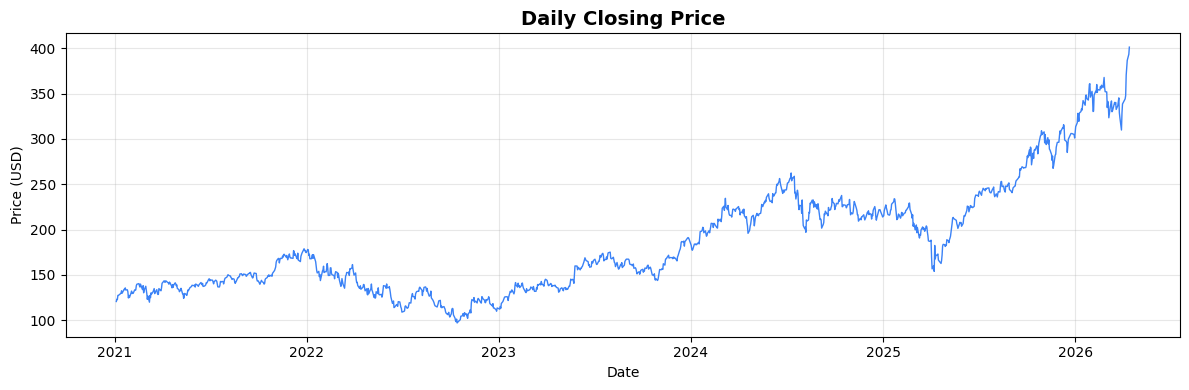

In [44]:
# =====================================================
# STEP 3: PLOT THE RAW PRICES
# =====================================================
# Let's just draw a simple line chart of Apple's price over time.

plt.figure(figsize=(12, 4))            # make the chart wide and not too tall
plt.plot(prices, color="#3B82F6",       # draw the line in blue
         linewidth=1)                   # not too thick
plt.title("Daily Closing Price", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")              # label the y-axis
plt.xlabel("Date")                     # label the x-axis
plt.grid(True, alpha=0.3)             # light grid lines to help read the chart
plt.tight_layout()                     # remove extra whitespace
plt.show()

# QUESTION TO THINK ABOUT:
# Do you see a TREND? (prices going up over time?)
# ARIMA needs to handle that trend — that's what the "I" (Integrated) part does!

---
## STEP 4 — Is the data "stationary"? (The ADF Test)

ARIMA needs **stationary** data. That means:
- **No trend** (not constantly going up or down)
- **Constant variance** (the wiggles stay about the same size)

Think of it like this:
- **Stationary** = a heartbeat monitor (bounces up and down around the same level)
- **Non-stationary** = a rocket taking off (keeps going up!)

We use the **ADF test** (Augmented Dickey-Fuller) to check:
- If p-value < 0.05 → Stationary (good!)
- If p-value > 0.05 → Non-stationary (we need to fix it)

In [45]:
# =====================================================
# STEP 4: CHECK IF DATA IS STATIONARY
# =====================================================

# Run the ADF test on the RAW prices
result = adfuller(prices)

# The p-value is the second thing the test gives us
p_value = result[1]

print("=== ADF Test on RAW Apple Prices ===")
print(f"P-value: {p_value:.4f}")
print()

if p_value < 0.05:
    print("Result: STATIONARY (p < 0.05)")
    print("The data is already flat enough. Lucky us!")
else:
    print("Result: NON-STATIONARY (p > 0.05)")
    print("The data has a trend! We need to DIFFERENCE it.")
    print("That means: instead of looking at PRICES,")
    print("we look at CHANGES in price (today minus yesterday).")

=== ADF Test on RAW Apple Prices ===
P-value: 0.9958

Result: NON-STATIONARY (p > 0.05)
The data has a trend! We need to DIFFERENCE it.
That means: instead of looking at PRICES,
we look at CHANGES in price (today minus yesterday).


---
## STEP 5 — "Differencing" — How we remove the trend

**Differencing** = subtract yesterday's price from today's price.

Instead of: `[100, 102, 105, 103]` (has a trend)

We get: `[+2, +3, -2]` (just the daily changes — much flatter!)

In [46]:
# =====================================================
# STEP 5: DIFFERENCING — REMOVE THE TREND
# =====================================================

# .diff() = today's price MINUS yesterday's price
# .dropna() = remove the first row (it has no "yesterday" to subtract)
prices_diff = prices.diff().dropna()

# Now test AGAIN — is the differenced data stationary?
result_diff = adfuller(prices_diff)
p_value_diff = result_diff[1]

print("=== ADF Test on DIFFERENCED Prices ===")
print(f"P-value: {p_value_diff:.6f}")
print()

if p_value_diff < 0.05:
    print("STATIONARY! The differencing worked!")
    print("This tells ARIMA to use d=1 (difference once).")
else:
    print("Still not stationary... we might need d=2.")

print()
print("Let's see what differenced data looks like...")

=== ADF Test on DIFFERENCED Prices ===
P-value: 0.000000

STATIONARY! The differencing worked!
This tells ARIMA to use d=1 (difference once).

Let's see what differenced data looks like...


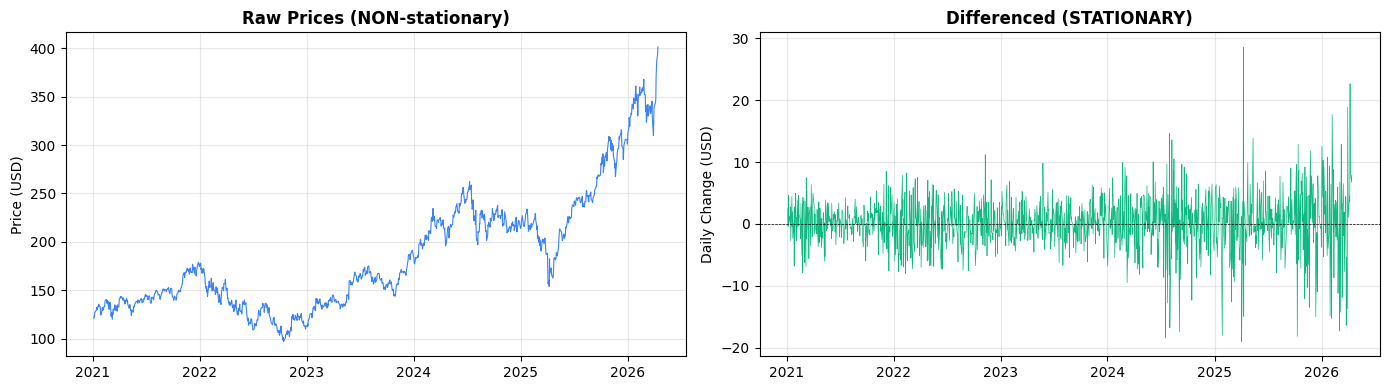

In [47]:
# =====================================================
# STEP 5b: PLOT — Before vs After Differencing
# =====================================================
# Side by side: raw prices (with trend) vs differenced (flat)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Raw prices (has a trend — goes up!)
axes[0].plot(prices, color="#3B82F6", linewidth=0.8)
axes[0].set_title("Raw Prices (NON-stationary)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# RIGHT: Differenced prices (flat — bounces around zero!)
axes[1].plot(prices_diff, color="#10B981", linewidth=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")  # zero line
axes[1].set_title("Differenced (STATIONARY)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Daily Change (USD)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SEE THE DIFFERENCE?
# Left chart: going UP (trend) → ARIMA can't work with this directly
# Right chart: bouncing around ZERO (no trend) → ARIMA loves this!

---
## STEP 6 — Split into TRAIN and TEST

Before we build our model, we need to **hide some data** so we can check if our predictions are any good.

- **Train set** = the data we SHOW the model (so it can learn patterns)
- **Test set** = the data we HIDE from the model (so we can grade it later)

It's like studying for a test:
- You study chapters 1-8 (train)
- The exam covers chapter 9-10 (test)
- If you get the exam right, your study method worked!

In [48]:
# =====================================================
# STEP 6: SPLIT DATA INTO TRAIN AND TEST
# =====================================================

# We'll use 85% of data for training, 15% for testing
train_size = int(len(prices) * 0.85)

# Split!
train = prices[:train_size]    # first 85% → model learns from this
test  = prices[train_size:]    # last 15%  → we check predictions against this

print(f"Total data points:  {len(prices)}")
print(f"Training set:       {len(train)} days  ({len(train)/len(prices)*100:.0f}%)")
print(f"Test set:           {len(test)} days  ({len(test)/len(prices)*100:.0f}%)")
print()
print(f"Train goes from {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test  goes from {test.index[0].date()} to {test.index[-1].date()}")

Total data points:  1325
Training set:       1126 days  (85%)
Test set:           199 days  (15%)

Train goes from 2021-01-04 to 2025-06-27
Test  goes from 2025-06-30 to 2026-04-14


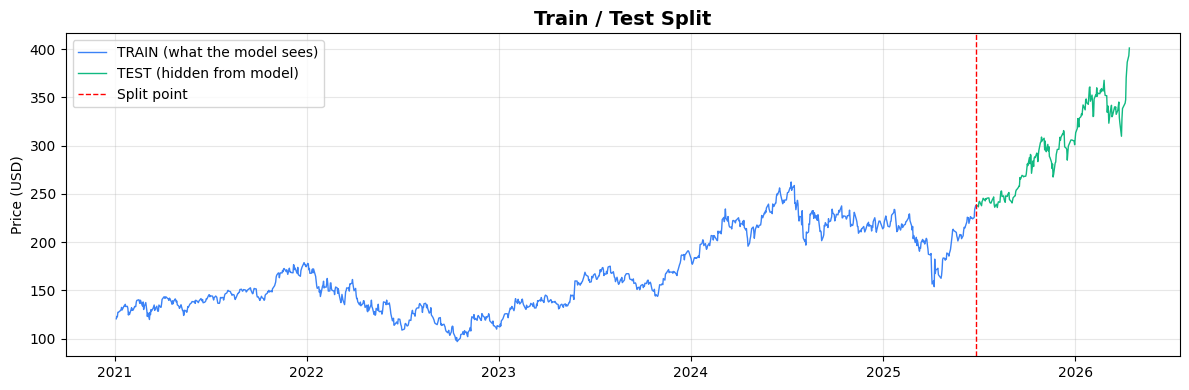

In [49]:
# =====================================================
# STEP 6b: VISUALIZE THE SPLIT
# =====================================================

plt.figure(figsize=(12, 4))

# Draw training data in BLUE
plt.plot(train, color="#3B82F6", linewidth=1, label="TRAIN (what the model sees)")

# Draw test data in GREEN
plt.plot(test, color="#10B981", linewidth=1, label="TEST (hidden from model)")

# Draw a vertical line where the split happens
plt.axvline(x=train.index[-1], color="red", linewidth=1, linestyle="--", label="Split point")

plt.title("Train / Test Split", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Everything on the LEFT of the red line → model can see
# Everything on the RIGHT of the red line → model is BLIND to this

---
## STEP 7 — Build the ARIMA model!

Now the fun part! We create an ARIMA model and ask it to **learn from the training data**.

We'll use **ARIMA(1, 1, 1)** — the simplest useful version:
- `p=1` → look at 1 past value
- `d=1` → difference once (removes the trend we saw earlier)
- `q=1` → learn from 1 past mistake

In [50]:
# =====================================================
# STEP 7: BUILD AND FIT THE ARIMA MODEL
# =====================================================

# Create the model: ARIMA(p=1, d=1, q=1)
#   p=1 → look at 1 past price
#   d=1 → difference once (remove trend)
#   q=1 → learn from 1 past error
my_order = (1, 1, 1)

# Create the model object (tell it: "here's the training data, here's the order")
model = ARIMA(train, order=my_order)

# .fit() → the model studies the data and learns the patterns
# (this is like the model "studying for the exam")
fitted_model = model.fit()

# Let's see a summary of what the model learned
print(f"Model: ARIMA{my_order}")
print(f"AIC: {fitted_model.aic:.0f}")
print()
print("AIC = a score that measures how good the model is.")
print("LOWER AIC = BETTER model.")
print()
print("The model has finished learning!")

Model: ARIMA(1, 1, 1)
AIC: 6220

AIC = a score that measures how good the model is.
LOWER AIC = BETTER model.

The model has finished learning!


---
## STEP 8 — Make predictions!

Now we ask the model: **"What do you think the price will be for the next N days?"**

The model will give us:
1. Its **best guess** (the forecast line)
2. A **confidence range** (upper and lower bounds — like saying "I'm 95% sure it'll be between X and Y")

In [58]:
# =====================================================
# STEP 8: MAKE PREDICTIONS (FORECAST)
# =====================================================

# How many days into the future do we want to predict?
# We'll predict exactly as many days as our test set has
steps = len(test)

# Ask the model to forecast!
# get_forecast() → gives us predictions + confidence interval
forecast = fitted_model.get_forecast(steps=steps)

# The best guess (predicted price for each day)
predicted_prices = forecast.predicted_mean

# The confidence interval (95% sure the real price is in this range)
confidence = forecast.conf_int(alpha=0.05)

# Create proper date labels for our predictions
# (business days only — stock market is closed on weekends!)
future_dates = pd.bdate_range(
    start=train.index[-1] + pd.Timedelta(days=1),
    periods=steps
)
predicted_prices.index = future_dates
confidence.index = future_dates

print(f"We predicted {steps} days into the future!")
print()
print("First 5 predictions:")
print(predicted_prices.head())
print()
print("First 5 confidence intervals:")
print(confidence.head())

We predicted 199 days into the future!

First 5 predictions:
2025-06-30    237.956686
2025-07-01    237.909503
2025-07-02    237.933384
2025-07-03    237.921297
2025-07-04    237.927415
Freq: B, Name: predicted_mean, dtype: float64

First 5 confidence intervals:
            lower SOXX  upper SOXX
2025-06-30  230.449918  245.463454
2025-07-01  227.697115  248.121892
2025-07-02  225.427145  250.439623
2025-07-03  223.555160  252.287434
2025-07-04  221.882480  253.972349


---
## STEP 9 — The Big Reveal: Plot the forecast!

This is the **money chart**. We'll see:
- **Blue** = training data (what the model studied)
- **Green** = actual prices (the truth the model never saw)
- **Red dashed** = the model's prediction
- **Pink shading** = the 95% confidence band

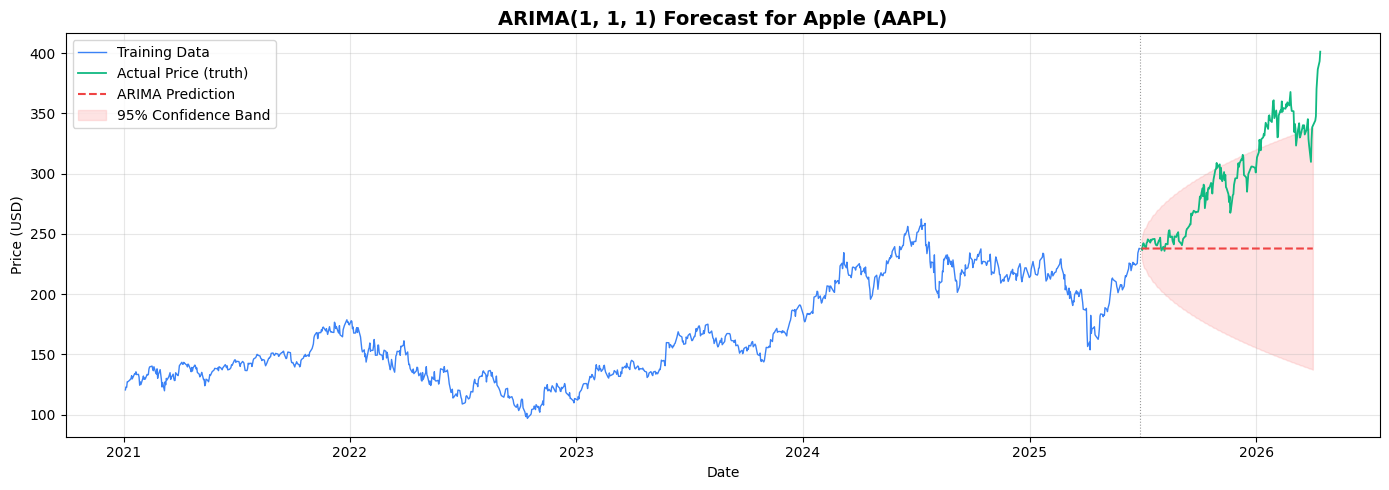

How did the model do? Compare the RED line to the GREEN line!
The closer they are, the better the prediction.


In [59]:
# =====================================================
# STEP 9: THE BIG CHART — FORECAST vs REALITY
# =====================================================

plt.figure(figsize=(14, 5))

# 1) Draw the TRAINING data (blue)
plt.plot(train.index, train.values,
         color="#3B82F6", linewidth=1, label="Training Data")

# 2) Draw the ACTUAL test data (green) — the truth!
plt.plot(test.index, test.values,
         color="#10B981", linewidth=1.3, label="Actual Price (truth)")

# 3) Draw the MODEL'S PREDICTION (red dashed line)
plt.plot(predicted_prices.index, predicted_prices.values,
         color="#EF4444", linewidth=1.5, linestyle="--", label="ARIMA Prediction")

# 4) Draw the CONFIDENCE BAND (pink shading)
#    This shows: "I'm 95% sure the price will be in this range"
lower = confidence.iloc[:, 0]   # lower bound
upper = confidence.iloc[:, 1]   # upper bound
plt.fill_between(confidence.index, lower, upper,
                 color="#FCA5A5", alpha=0.3, label="95% Confidence Band")

# 5) Draw a vertical line at the split point
plt.axvline(x=train.index[-1], color="#999999", linewidth=0.8, linestyle=":")

# Make it pretty
plt.title(f"ARIMA{my_order} Forecast for Apple (AAPL)", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("How did the model do? Compare the RED line to the GREEN line!")
print("The closer they are, the better the prediction.")

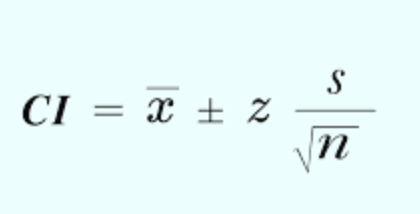

---
## STEP 10 — Zoom in: How close was the prediction?

Let's zoom into JUST the test period so we can really see how the red line compares to the green line.

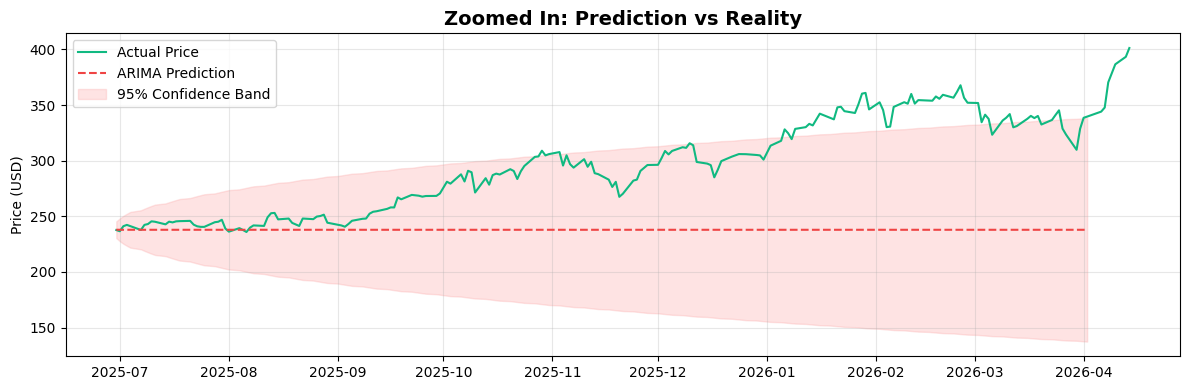

In [53]:
# =====================================================
# STEP 10: ZOOMED-IN VIEW (test period only)
# =====================================================

plt.figure(figsize=(12, 4))

# Actual prices (GREEN)
plt.plot(test.index, test.values,
         color="#10B981", linewidth=1.5, label="Actual Price")

# Predicted prices (RED dashed)
plt.plot(predicted_prices.index, predicted_prices.values,
         color="#EF4444", linewidth=1.5, linestyle="--", label="ARIMA Prediction")

# Confidence band (PINK)
plt.fill_between(confidence.index, lower, upper,
                 color="#FCA5A5", alpha=0.3, label="95% Confidence Band")

plt.title("Zoomed In: Prediction vs Reality", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NOTICE: The pink band gets WIDER as we go further into the future.
# That makes sense! It's harder to predict next MONTH than next DAY.

---
## STEP 11 — Grade the model: How wrong was it?

We need **numbers**, not just eyeballing the chart. Let's calculate:

- **MAE** (Mean Absolute Error) = "On average, how many dollars off was each prediction?"
- **MAPE** (Mean Absolute Percentage Error) = "On average, how many PERCENT off was each prediction?"

In [54]:
# =====================================================
# STEP 11: MEASURE THE ERROR
# =====================================================

# Get the actual and predicted values lined up
actual    = test.values                                 # the truth
predicted = predicted_prices.values[:len(actual)]       # our guess

# MAE = Mean Absolute Error
# "On average, how many dollars off?"
# Step by step:
#   1. Subtract: actual - predicted  (how far off each day?)
#   2. Absolute value: ignore negative signs (we don't care if it's $5 too high or $5 too low)
#   3. Average: take the mean of all those errors
errors = actual - predicted             # raw errors (some positive, some negative)
abs_errors = np.abs(errors)             # absolute errors (all positive)
mae = np.mean(abs_errors)               # average of absolute errors

# MAPE = Mean Absolute Percentage Error
# "On average, what percent off?"
pct_errors = abs_errors / actual * 100  # express each error as a percentage
mape = np.mean(pct_errors)              # average percentage error

print("=" * 50)
print(f"     MODEL REPORT CARD: ARIMA{my_order}")
print("=" * 50)
print()
print(f"  MAE  = ${mae:.2f}")
print(f"         (On average, the prediction was ${mae:.2f} off)")
print()
print(f"  MAPE = {mape:.1f}%")
print(f"         (On average, the prediction was {mape:.1f}% off)")
print()
print("=" * 50)
print()

if mape < 5:
    print("Grade: A+ ... Excellent! Under 5% error!")
elif mape < 10:
    print("Grade: B  ... Good! Under 10% error.")
elif mape < 20:
    print("Grade: C  ... Okay. There's room for improvement.")
else:
    print("Grade: D  ... ARIMA struggled here. Try a different model?")

     MODEL REPORT CARD: ARIMA(1, 1, 1)

  MAE  = $59.06
         (On average, the prediction was $59.06 off)

  MAPE = 18.3%
         (On average, the prediction was 18.3% off)


Grade: C  ... Okay. There's room for improvement.


---
## STEP 12 — Check the "leftovers" (Residuals)

**Residuals** = the mistakes the model made on the TRAINING data.

If the model is good, the residuals should look like **random noise** — no patterns, just chaos. If you see patterns in the residuals, the model missed something.

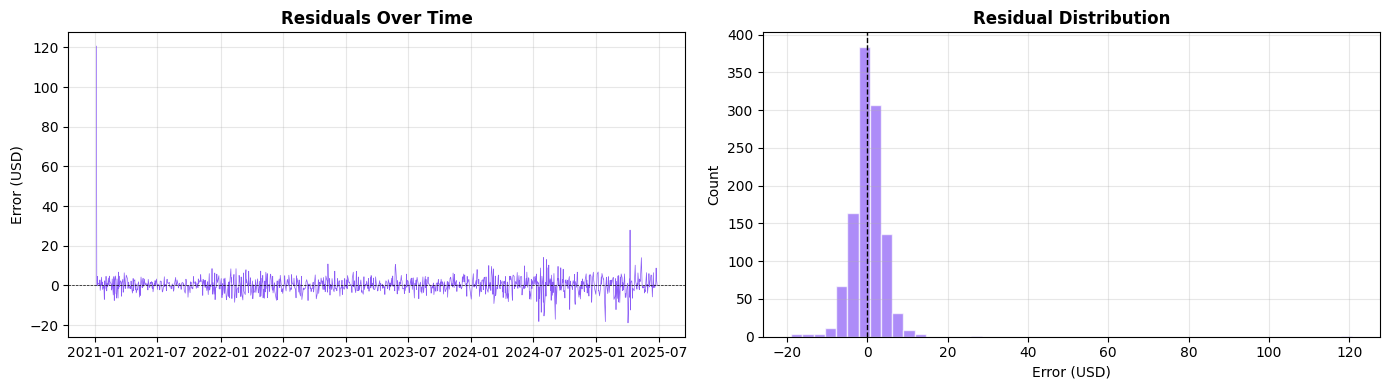

In [55]:
# =====================================================
# STEP 12: RESIDUAL ANALYSIS
# =====================================================
# "Residuals" = the errors the model made during training
# Good residuals = random noise (no patterns)

residuals = fitted_model.resid  # get the residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# LEFT: Plot residuals over time
# We want to see: random scatter around zero (no trend, no pattern)
axes[0].plot(residuals, color="#8B5CF6", linewidth=0.5)
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Residuals Over Time", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Error (USD)")
axes[0].grid(True, alpha=0.3)

# RIGHT: Histogram of residuals
# We want to see: a bell curve centered at zero
axes[1].hist(residuals, bins=50, color="#8B5CF6", alpha=0.7, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Residual Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Error (USD)")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
# Left chart  → should look like random static/noise (no patterns)
# Right chart → should look like a bell curve centered at 0

---
## STEP 13 — BONUS: Try different ARIMA orders!

Want to experiment? Let's try a few different `(p, d, q)` combinations and see which one gets the **lowest AIC** (best score).

This is like trying on different shoes to see which pair fits best.

In [56]:
# =====================================================
# STEP 13: TRY DIFFERENT ARIMA ORDERS
# =====================================================
# Let's test a few combinations and compare their AIC scores.
# Remember: LOWER AIC = BETTER

# List of orders to try
orders_to_try = [
    (1, 1, 0),   # AR only, no MA
    (0, 1, 1),   # MA only, no AR
    (1, 1, 1),   # the one we already tried
    (2, 1, 1),   # look at 2 past values
    (1, 1, 2),   # learn from 2 past mistakes
    (2, 1, 2),   # more complex
]

print("Testing different ARIMA orders...")
print("=" * 45)
print(f"{'Order':<15} {'AIC':>10}  {'Verdict'}")
print("-" * 45)

best_aic = np.inf
best_order = None

for order in orders_to_try:
    try:
        # Fit each model
        temp_model = ARIMA(train, order=order).fit()
        aic = temp_model.aic

        # Track the best one
        if aic < best_aic:
            best_aic = aic
            best_order = order

        print(f"ARIMA{str(order):<10} {aic:>10,.0f}")
    except Exception:
        print(f"ARIMA{str(order):<10}     FAILED  (bad combo)")

print("-" * 45)
print(f"\nWINNER: ARIMA{best_order} with AIC = {best_aic:,.0f}")
print("This is the best-fitting model from our list!")

Testing different ARIMA orders...
Order                  AIC  Verdict
---------------------------------------------
ARIMA(1, 1, 0)       6,220
ARIMA(0, 1, 1)       6,221
ARIMA(1, 1, 1)       6,220
ARIMA(2, 1, 1)       6,222
ARIMA(1, 1, 2)       6,222
ARIMA(2, 1, 2)       6,222
---------------------------------------------

WINNER: ARIMA(1, 1, 1) with AIC = 6,220
This is the best-fitting model from our list!


---
## STEP 14 — Final chart: Best model forecast

Let's re-run the forecast with our **best order** and see how it compares to ARIMA(1,1,1).

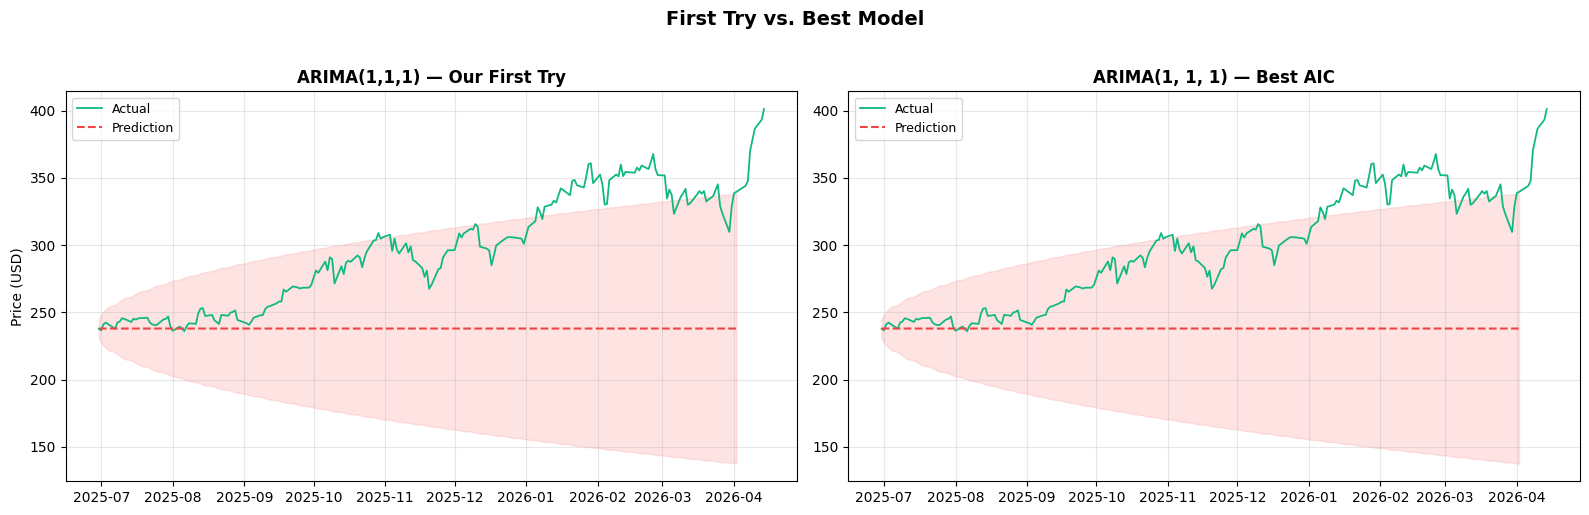

In [57]:
# =====================================================
# STEP 14: FORECAST WITH THE BEST ORDER
# =====================================================

# Fit the best model
best_model = ARIMA(train, order=best_order).fit()

# Forecast
best_forecast = best_model.get_forecast(steps=len(test))
best_pred = best_forecast.predicted_mean
best_ci   = best_forecast.conf_int(alpha=0.05)

# Assign dates
best_pred.index = future_dates
best_ci.index   = future_dates

# ── Plot both forecasts side by side ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LEFT: Our first attempt ARIMA(1,1,1)
ax = axes[0]
ax.plot(test.index, test.values, color="#10B981", linewidth=1.3, label="Actual")
ax.plot(predicted_prices.index, predicted_prices.values,
        color="#EF4444", linewidth=1.5, linestyle="--", label="Prediction")
ax.fill_between(confidence.index, confidence.iloc[:, 0], confidence.iloc[:, 1],
                color="#FCA5A5", alpha=0.3)
ax.set_title(f"ARIMA(1,1,1) — Our First Try", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylabel("Price (USD)")

# RIGHT: The best model
ax = axes[1]
ax.plot(test.index, test.values, color="#10B981", linewidth=1.3, label="Actual")
ax.plot(best_pred.index, best_pred.values,
        color="#EF4444", linewidth=1.5, linestyle="--", label="Prediction")
ax.fill_between(best_ci.index, best_ci.iloc[:, 0], best_ci.iloc[:, 1],
                color="#FCA5A5", alpha=0.3)
ax.set_title(f"ARIMA{best_order} — Best AIC", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("First Try vs. Best Model", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## RECAP — What did we learn?

### The ARIMA recipe (5 steps):

```
1. GET DATA         → yfinance gave us real stock prices
2. CHECK STATIONARITY → ADF test told us we need differencing
3. SPLIT DATA       → 85% train, 15% test (hide the answers!)
4. FIT THE MODEL    → ARIMA(p,d,q) learned patterns from training data
5. FORECAST         → the model predicted future prices
```

### Key vocabulary:
| Term | Plain English |
|------|---------------|
| **Stationary** | Data that doesn't trend up or down |
| **Differencing** | Subtracting yesterday from today to kill the trend |
| **AIC** | Score to compare models (lower = better) |
| **Confidence Interval** | "I'm 95% sure the answer is between X and Y" |
| **Residuals** | The model's mistakes — should be random noise |
| **MAE** | Average dollar error per prediction |
| **MAPE** | Average percentage error per prediction |

### What ARIMA is good at:
- Short-term forecasts on stable data
- Capturing simple linear trends and patterns
- Giving you a confidence range (not just a single guess)

### What ARIMA is NOT good at:
- Predicting crashes or sudden spikes
- Handling stocks with wild, explosive growth (like NVDA)
- Long-term forecasts (uncertainty grows fast!)

---
*Now you know ARIMA! Try changing the ticker from "AAPL" to any stock you like and re-run the notebook.*